In [ ]:
!pip install tensorflow pandas numpy scikit-learn matplotlib joblib

In [ ]:
import os
import torch
import joblib
import pandas as pd
import numpy as np

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/unsw_data/UNSW_NB15_training-set.csv"
)

In [ ]:
df = df.dropna()

In [ ]:
texts = (
    df.astype(str)
    .apply(lambda x: ' '.join(x), axis=1)
)

In [ ]:
labels = df["label"]

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(labels)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=128
)

In [ ]:
train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": list(y_train)
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": list(y_test)
})

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_encoder.classes_)
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./logs",
    logging_steps=100
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [ ]:
trainer.train()

Step,Training Loss
100,0.098628
200,0.000144
300,0.000075
400,0.000049
500,0.000036
600,0.000027
700,0.000022
800,0.000018
900,0.000015
1000,0.000013


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=24702, training_loss=0.000736491175613504, metrics={'train_runtime': 6898.9006, 'train_samples_per_second': 28.642, 'train_steps_per_second': 3.581, 'total_flos': 1.29973572459648e+16, 'train_loss': 0.000736491175613504, 'epoch': 3.0})

In [ ]:
SAVE_DIR = "/content/bert_unsw_model"

model.save_pretrained(SAVE_DIR)

tokenizer.save_pretrained(SAVE_DIR)

joblib.dump(
    label_encoder,
    f"{SAVE_DIR}/label_encoder.pkl"
)

print("BERT model saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model saved


In [ ]:
!ls ./results

checkpoint-1000   checkpoint-15500  checkpoint-21500  checkpoint-500
checkpoint-10000  checkpoint-16000  checkpoint-22000  checkpoint-5000
checkpoint-10500  checkpoint-16500  checkpoint-22500  checkpoint-5500
checkpoint-11000  checkpoint-17000  checkpoint-23000  checkpoint-6000
checkpoint-11500  checkpoint-17500  checkpoint-23500  checkpoint-6500
checkpoint-12000  checkpoint-18000  checkpoint-24000  checkpoint-7000
checkpoint-12500  checkpoint-18500  checkpoint-24500  checkpoint-7500
checkpoint-13000  checkpoint-19000  checkpoint-24702  checkpoint-8000
checkpoint-13500  checkpoint-19500  checkpoint-2500   checkpoint-8500
checkpoint-14000  checkpoint-2000   checkpoint-3000   checkpoint-9000
checkpoint-14500  checkpoint-20000  checkpoint-3500   checkpoint-9500
checkpoint-1500   checkpoint-20500  checkpoint-4000
checkpoint-15000  checkpoint-21000  checkpoint-4500


In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "./results/checkpoint-24702"
)

print("Checkpoint loaded")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Checkpoint loaded


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
text = "normal network traffic"

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

inputs = {k: v.to(device) for k, v in inputs.items()}

outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1)

print(
    label_encoder.inverse_transform(
        prediction.cpu().numpy()
    )
)

[0]


In [ ]:
print(label_encoder.classes_)

[0 1]


In [ ]:
print(label_encoder.inverse_transform([0]))

[0]


In [ ]:
df["label"].value_counts()

,count
label,
1,45332
0,37000


In [ ]:
text = "DoS attack detected from multiple IP addresses"

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

inputs = {k: v.to(device) for k, v in inputs.items()}

outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1)

pred = prediction.cpu().numpy()[0]

if pred == 1:
    print("Attack")
else:
    print("Normal")

Attack


In [ ]:
import torch.nn.functional as F

probs = F.softmax(outputs.logits, dim=1)

print(probs)

tensor([[8.9819e-09, 1.0000e+00]], device='cuda:0', grad_fn=<SoftmaxBackward0>)


In [ ]:
predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=1)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7418
           1       1.00      1.00      1.00      9049

    accuracy                           1.00     16467
   macro avg       1.00      1.00      1.00     16467
weighted avg       1.00      1.00      1.00     16467



Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7418
      Attack       1.00      1.00      1.00      9049

    accuracy                           1.00     16467
   macro avg       1.00      1.00      1.00     16467
weighted avg       1.00      1.00      1.00     16467



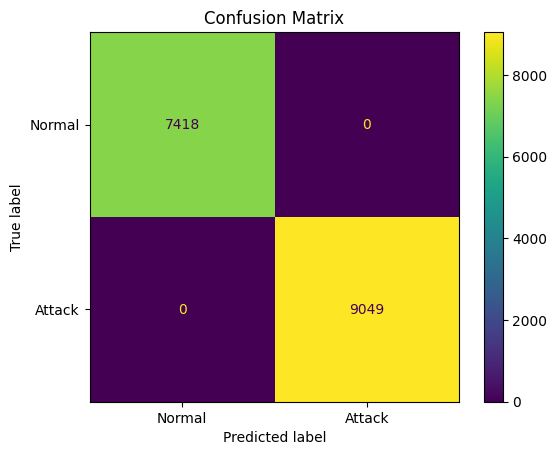

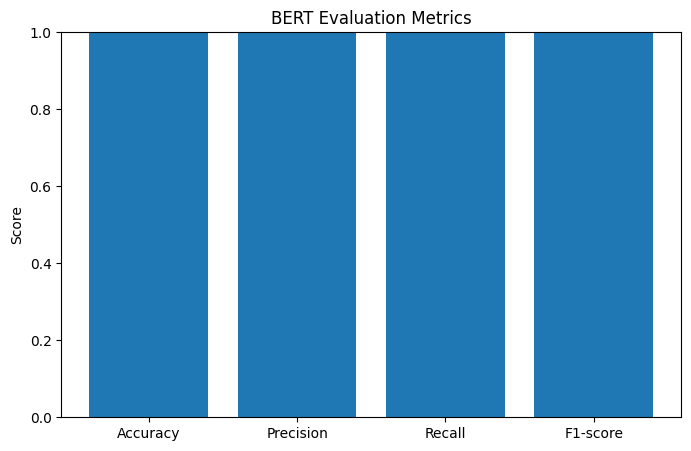

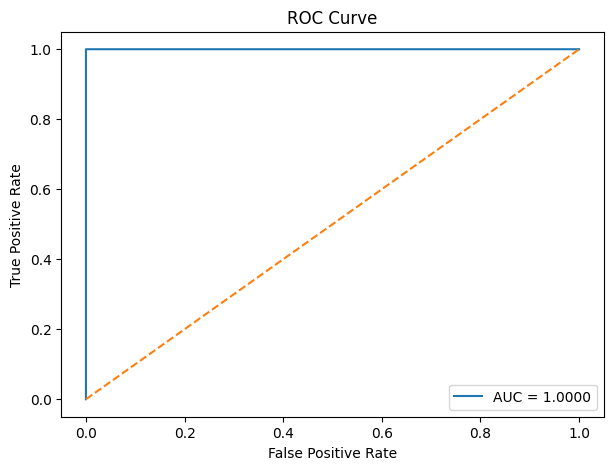

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
import torch.nn.functional as F

# Predict
predictions = trainer.predict(test_dataset)

logits = predictions.predictions
y_pred = np.argmax(logits, axis=1)
y_true = y_test

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Normal", "Attack"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Bar Chart Metrics
metrics_names = ["Accuracy", "Precision", "Recall", "F1-score"]
metrics_values = [acc, prec, rec, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics_names, metrics_values)
plt.ylim(0, 1)
plt.title("BERT Evaluation Metrics")
plt.ylabel("Score")
plt.show()

# ROC Curve
probs = F.softmax(torch.tensor(logits), dim=1).numpy()
attack_probs = probs[:, 1]

fpr, tpr, thresholds = roc_curve(y_true, attack_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
df_test_real = pd.read_csv(
    "/content/drive/MyDrive/unsw_data/UNSW_NB15_testing-set.csv"
)

In [ ]:
df_test_real = df_test_real.dropna()

In [ ]:
texts_real = (
    df_test_real.astype(str)
    .apply(lambda x: ' '.join(x), axis=1)
)

labels_real = df_test_real["label"]

In [ ]:
X_real = tokenizer(
    list(texts_real),
    truncation=True,
    padding=True,
    max_length=128
)

In [ ]:
real_dataset = Dataset.from_dict({
    "input_ids": X_real["input_ids"],
    "attention_mask": X_real["attention_mask"],
    "labels": list(labels_real)
})

In [ ]:
predictions_real = trainer.predict(real_dataset)

In [ ]:
y_pred_real = np.argmax(
    predictions_real.predictions,
    axis=1
)

from sklearn.metrics import classification_report

print(
    classification_report(
        labels_real,
        y_pred_real
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56000
           1       1.00      1.00      1.00    119341

    accuracy                           1.00    175341
   macro avg       1.00      1.00      1.00    175341
weighted avg       1.00      1.00      1.00    175341



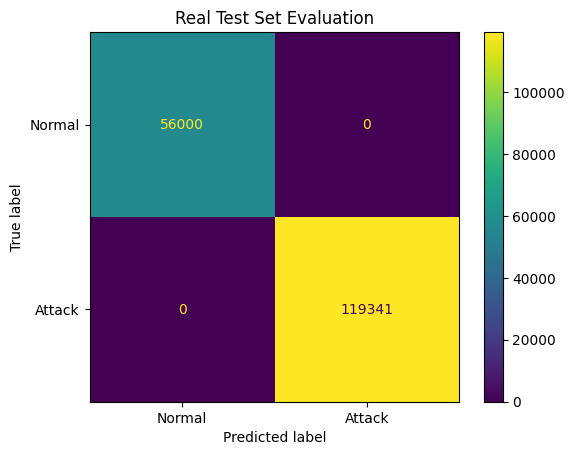

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(labels_real, y_pred_real)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)

disp.plot()

plt.title("Real Test Set Evaluation")

plt.show()